## **CCS 249: Natural Language Processing**
## Exercise 6
### **Submitted by:**
### Escrupulo, Ma. Asherah Francine Faith S.
### Porras, Jessie Loraine P.
### BSCS 3-B AI


---



## **FINANCE TWEETS CLASSIFICATION USING RoBERTA**

In [ ]:
# installing requirements

!pip install -q transformers datasets evaluate accelerate scikit-learn

In [ ]:
# connecting to Hugging Face

from google.colab import userdata
from huggingface_hub import login

my_token = userdata.get('HF_TOKEN')

login(token = my_token)

In [ ]:
# loading the dataset from Hugging face

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("zeroshot/twitter-financial-news-topic")

#shrinking dataset due to technical constraints
small_train_dataset = dataset["train"].shuffle(seed=42).select(range(5000))
small_eval_dataset = dataset["validation"].shuffle(seed=42).select(range(1000))

# peeking at the dataset
pd.DataFrame(small_train_dataset[:10])

README.md: 0.00B [00:00, ?B/s]

topic_train.csv: 0.00B [00:00, ?B/s]

topic_valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/16990 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4117 [00:00<?, ? examples/s]

,text,label
0,The Russell value index has risen by just 1% s...,15
1,Heard on the Street: Tesla’s production proble...,2
2,An expanse of heat will spread across the cent...,9
3,Vulnerabilities in a GPS device could give hac...,9
4,Stocks making the biggest moves premarket: Bak...,19
5,"Glancy Prongay &amp; Murray LLP, a Leading Sec...",12
6,"Lipsticks, lattes . . . and now labradors: JAB...",9
7,Handelsbanken's Q2 profit misses forecasts on ...,7
8,"In Israel, slain soldiers are becoming dads th...",9
9,U.S HOUSING STARTS (MOM) (JUN) ACTUAL: -2.0% V...,14


## **Load Tokenizer and RoBERTA model**

In [ ]:
# load tokenizer and roberta-base model

from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "roberta-base"

# Class labels for the finance-related tweets
id2label = {
    "LABEL_0": "Analyst Update",
    "LABEL_1": "Fed | Central Banks",
    "LABEL_2": "Company | Product News",
    "LABEL_3": "Treasuries | Corporate Debt",
    "LABEL_4": "Dividend",
    "LABEL_5": "Earnings",
    "LABEL_6": "Energy | Oil",
    "LABEL_7": "Financials",
    "LABEL_8": "Currencies",
    "LABEL_9": "General News | Opinion",
    "LABEL_10": "Gold | Metals | Materials",
    "LABEL_11": "IPO",
    "LABEL_12": "Legal | Regulation",
    "LABEL_13": "M&A | Investments",
    "LABEL_14": "Macro",
    "LABEL_15": "Markets",
    "LABEL_16": "Politics",
    "LABEL_17": "Personnel Change",
    "LABEL_18": "Stock Commentary",
    "LABEL_19": "Stock Movement",
}
label2id = {v: k for k, v in id2label.items()}


tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
  return tokenizer(examples["text"], truncation = True, max_length = 128)

tokenized_train = small_train_dataset.map(tokenize_function, batched = True)
tokenized_eval = small_eval_dataset.map(tokenize_function, batched = True)



config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

## **Tokenizing the Dataset**

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = 20,
    id2label = id2label,
    label2id = label2id
)



model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## **Setting up Training and Evaluation**

In [ ]:
import numpy as np
import evaluate
from sklearn.metrics import accuracy_score
from transformers import TrainingArguments, Trainer

print("Libraries installed successfully!")

Libraries installed successfully!


In [ ]:
# evaluation metrics

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Safety catch for the tuple output
    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        # Fixed the typo here!
        "f1_weighted": f1.compute(predictions=predictions, references=labels, average="weighted")["f1"],
    }

In [ ]:
# configuring training parameters

training_args = TrainingArguments(
    output_dir = "./results",
    eval_strategy = "epoch",
    learning_rate = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 3,
    weight_decay = 0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=5,
    report_to="none"
)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = tokenized_train,
    eval_dataset = tokenized_eval,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics = compute_metrics,
)

print("model configured successfully!")

model configured successfully!


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.519257,0.621224,0.840000,0.826542
2,0.328739,0.469031,0.871000,0.868465
3,0.172912,0.448457,0.876000,0.873224


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=939, training_loss=0.697575622124159, metrics={'train_runtime': 396.5313, 'train_samples_per_second': 37.828, 'train_steps_per_second': 2.368, 'total_flos': 577075237645632.0, 'train_loss': 0.697575622124159, 'epoch': 3.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.44845709204673767,
 'eval_accuracy': 0.876,
 'eval_f1_weighted': 0.8732244798617614,
 'eval_runtime': 4.3632,
 'eval_samples_per_second': 229.189,
 'eval_steps_per_second': 14.439,
 'epoch': 3.0}

In [ ]:
trainer.save_model("./finance-roberta-final")
tokenizer.save_pretrained("./finance-roberta-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./finance-roberta-final/tokenizer_config.json',
 './finance-roberta-final/tokenizer.json')

## Finance headlines for test_sentences from **CNBC**:
https://www.cnbc.com/finance/

In [ ]:
from transformers import pipeline

# redefine clean topics dictionary
topics = {
    "LABEL_0": "Analyst Update",
    "LABEL_1": "Fed | Central Banks",
    "LABEL_2": "Company | Product News",
    "LABEL_3": "Treasuries | Corporate Debt",
    "LABEL_4": "Dividend",
    "LABEL_5": "Earnings",
    "LABEL_6": "Energy | Oil",
    "LABEL_7": "Financials",
    "LABEL_8": "Currencies",
    "LABEL_9": "General News | Opinion",
    "LABEL_10": "Gold | Metals | Materials",
    "LABEL_11": "IPO",
    "LABEL_12": "Legal | Regulation",
    "LABEL_13": "M&A | Investments",
    "LABEL_14": "Macro",
    "LABEL_15": "Markets",
    "LABEL_16": "Politics",
    "LABEL_17": "Personnel Change",
    "LABEL_18": "Stock Commentary",
    "LABEL_19": "Stock Movement",
}

# Force the model to learn the English labels
# This takes "LABEL_0", splits it at the "_", grabs the "0", and turns it into an integer
model.config.id2label = {int(k.split("_")[1]): v for k, v in topics.items()}
model.config.label2id = {v: int(k.split("_")[1]) for k, v in topics.items()}

# Rebuild the pipeline
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

# Test sentences
test_sentences = [
    "Stocks making the biggest moves premarket: GE Vernova, Vertiv, Best Buy & more",
    "Cursor in talks to raise $2 billion funding round at valuation of over $50 billion",
    "Alibaba is making the AI investments analysts want to see",
    "Mortgage rates sink again, and home buyers jump back in",
    "Analysts expect limited impact on AST SpaceMobile’s finances, but worry the news could dent investor sentiment on the stock.",
    "The stock fell more than 5% after a rocket designed by Jeff Bezos’ space technology company Blue Origin placed the satellite in a lower-than-planned orbit on Sunday.",
    "Howard Marks says there are few cheap stocks: ‘Bargains come when people panic’",
    "Retail traders pile into Allbirds on AI pivot. History shows it won’t end well",
    "Morgan Stanley tops estimates as trading revenue beats by nearly $1 billion",
    "Dimon says Anthropic’s Mythos reveals ‘more vulnerabilities’ for cyberattacks"
]

results = classifier(test_sentences)

# Print results

for text, result in zip(test_sentences, results):
    print(f"Text: {text}")
    print(f"Prediction: {result['label']} (Confidence Score: {result['score']:.2f})\n")

Text: Stocks making the biggest moves premarket: GE Vernova, Vertiv, Best Buy & more
Prediction: Stock Movement (Confidence Score: 0.78)

Text: Cursor in talks to raise $2 billion funding round at valuation of over $50 billion
Prediction: Company | Product News (Confidence Score: 0.98)

Text: Alibaba is making the AI investments analysts want to see
Prediction: Company | Product News (Confidence Score: 0.94)

Text: Mortgage rates sink again, and home buyers jump back in
Prediction: Fed | Central Banks (Confidence Score: 0.62)

Text: Analysts expect limited impact on AST SpaceMobile’s finances, but worry the news could dent investor sentiment on the stock.
Prediction: Analyst Update (Confidence Score: 0.74)

Text: The stock fell more than 5% after a rocket designed by Jeff Bezos’ space technology company Blue Origin placed the satellite in a lower-than-planned orbit on Sunday.
Prediction: Stock Movement (Confidence Score: 0.95)

Text: Howard Marks says there are few cheap stocks: ‘Barga

In [ ]:
# Fixing the labels
with open(f"{model_path}/config.json", "r") as f:
    config_data = json.load(f)

# Fix to become integer compatible
if "id2label" in config_data:
    num_labels = len(config_data["id2label"])
    config_data["id2label"] = {str(i): f"LABEL_{i}" for i in range(num_labels)}
    config_data["label2id"] = {f"LABEL_{i}": i for i in range(num_labels)}

with open(f"{model_path}/config.json", "w") as f:
    json.dump(config_data, f, indent=2)

print("Config Fixed! No more errors.")

Config Fixed! No more errors.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: /content/finance-roberta-final
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.bias      | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
pooler.dense.weight        | MISSING    | 
pooler.dense.bias          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


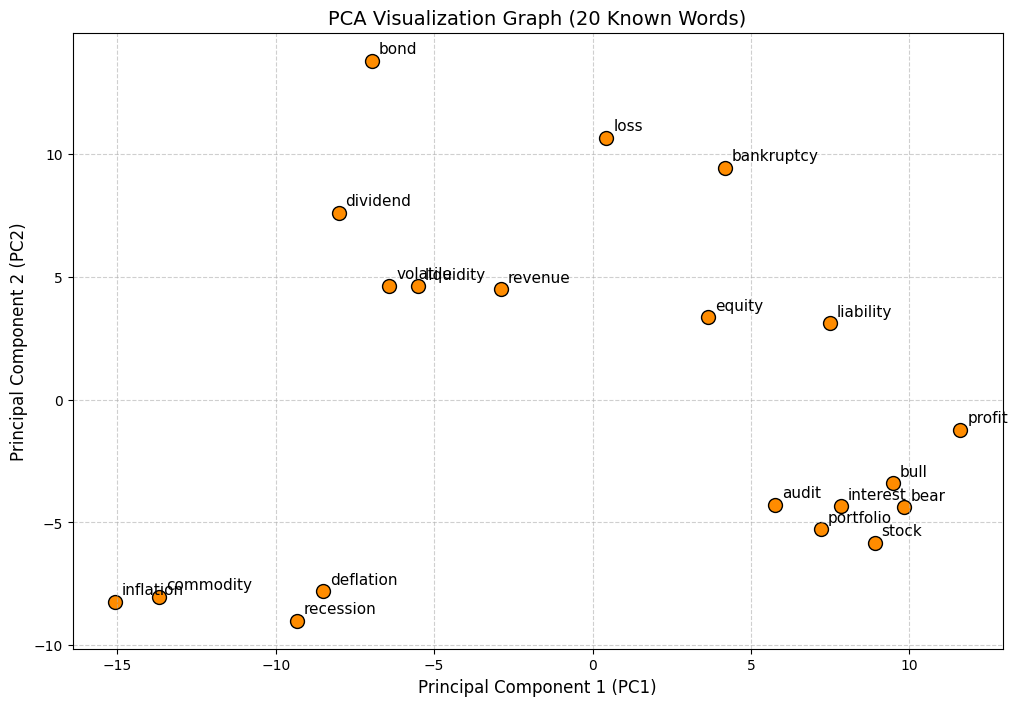

In [ ]:
# PCA Visualization

import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel

model_path = "/content/finance-roberta-final"

# LOAD USING AUTO CLASSES
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModel.from_pretrained(model_path)
model.eval()

# Generated Words for PCA VISUALIZATION (20 Known Words)
words = ["profit", "loss", "dividend", "equity", "liability",
         "bull", "bear", "inflation", "deflation", "revenue",
         "interest", "bankruptcy", "liquidity", "portfolio", "stock",
         "bond", "recession", "audit", "volatile", "commodity"]

word_vectors = []
for word in words:
    inputs = tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        # Kunin ang numeric representation ng word
        vector = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        word_vectors.append(vector)

# Reduce dimensions to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(np.array(word_vectors))

# PLOTTING
plt.figure(figsize=(12, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], c='darkorange', edgecolors='black', s=100)

# Annotation for each word
for i, word in enumerate(words):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=11)

# PCA Visualization Graph w/labels
plt.title("PCA Visualization Graph (20 Known Words)", fontsize=14)
plt.xlabel("Principal Component 1 (PC1)", fontsize=12) # X Label
plt.ylabel("Principal Component 2 (PC2)", fontsize=12) # Y Label
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()